# Modeling like in the Bachelor Thesis

In [1]:
import os
from pathlib import Path

import pandas as pd


os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())


dataPathCSV = str(Path.cwd()) + r"\data\csv" + "\\"
PlotPath = str(Path.cwd()) + r"\out\plots\modeling\BA" + "\\"

Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
data_train = pd.read_csv(dataPathCSV + r"Processed Files\dataset_train_converted_to_csv.csv", encoding='cp1252')
data_test = pd.read_csv(dataPathCSV + r"Processed Files\dataset_test_converted_to_csv.csv", encoding='cp1252')


In [3]:
import pickle
from data_processing.LabelLut import LABEL_OTHER_DEVICE

with open(dataPathCSV + r'Processed Files\Dataset_Classification_label_List_Train.pickle', 'rb') as f:
    labels_train = pickle.load(f)

data_train['Label'] = labels_train

with open(dataPathCSV + r"Processed Files\Dataset_Classification_label_List_Test.pickle", 'rb') as f:
    labels_test = pickle.load(f)

data_test['Label'] = labels_test
data_train = data_train[data_train['Label'] != LABEL_OTHER_DEVICE]

data_train.sort_values(by=['Time'], inplace=True, ascending=True)
data_test.sort_values(by=['Time'], inplace=True, ascending=True)

labels_train = data_train['Label']
labels_test = data_test['Label']

In [4]:
data_train_other_device = pd.read_csv(dataPathCSV + r"\other Device\other Device.csv", encoding='cp1252')

In [5]:
picklePath = str(Path.cwd()) + r"\out\pickle_objects\processing_pipeline" + "\\"
import pickle

with open(picklePath + 'Processing Pipeline.pickle', 'rb') as f:
    AnalysisPipeline = pickle.load(f)

AnalysisPipeline.print(priority=True, flags=True)

Processing Pipeline
	10 Pre Processing: Pre Processing
		10 Select and order columns
		15 Company ID and UUID
			10 Fill Company ID with None
			20 Fill UUID with None
			30 Replace Company IDs
			40 Replace Company UUIDs
		20 MS Data Processing
			10 Fill MS Data with empty String
			20 Length of MS Data
			30 Continuity Type
			40 Drop MS Data Column
		25 Service Data Processing
			10 Fill Service Data with empty String
			20 Length of Service Data
			30 Samsung Type
			40 Drop Service Data Column
		30 Fill Numeric NA with 0
		40 Fill String NA with None
		50 Broadcast
		60 Datetime conversion
		80 Order DataFrame
		90 Convert object type to string
	20 Dummy Processing: Dummy Processing
		30 Dummies Channel
		40 Dummies AD Type
		50 Dummies Company
		55 Dummies UUID
		70 Dummies PDU Type
		80 Dummies Continuity Type
		90 Dummies SmartTag Type
	30 Labeling: Labeling
		10 Labeling auto: Labeling auto
			Label Apple AirTag and Owner Device: Label Apple AirTag and nearby Owner Device
			

In [6]:
with open(picklePath + 'Pre Processing.pickle', 'rb') as f:
    flag_preProcessing = pickle.load(f)


with open(picklePath + 'Dummy Processing.pickle', 'rb') as f:
    flag_dummy = pickle.load(f)

In [7]:
from tgf import Flag, Pipeline

process_flag = Flag("Proces", parents=[flag_dummy, flag_preProcessing])

data_train_processed = AnalysisPipeline.process(data_train, flag=process_flag)
data_train_processed['Label'] = labels_train



data_test_processed = AnalysisPipeline.process(data_test, flag=process_flag)
data_test_processed['Label'] = labels_test

data_other_device_processed = AnalysisPipeline.process(data_train_other_device.iloc[:15_000, :], flag=process_flag)

data_other_device_processed['Label'] = LABEL_OTHER_DEVICE

data_train_processed = pd.concat([data_train_processed, data_other_device_processed])

In [8]:
dropColumns = ['Time', 'Source', 'Length Packet', 'Broadcast', 'Continuity Type', 'CH 37', 'CH 38', 'CH 39']

In [9]:
data_train_processed.drop(columns=dropColumns, inplace=True)
data_test_processed.drop(columns=dropColumns, inplace=True)

In [10]:
data_train_processed.info()

<class 'pandas.DataFrame'>
Index: 30000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Length Header                               30000 non-null  int64
 1   Length MS Data                              30000 non-null  int64
 2   Length Service Data                         30000 non-null  int64
 3   AD Manufacturer Specific                    30000 non-null  int64
 4   AD Flags                                    30000 non-null  int64
 5   AD Tx Power Level                           30000 non-null  int64
 6   AD Service Data - 16 bit UUID               30000 non-null  int64
 7   AD 16-bit Service Class UUIDs               30000 non-null  int64
 8   AD 16-bit Service Class UUIDs (incomplete)  30000 non-null  int64
 9   AD Other                                    30000 non-null  int64
 10  COMP Apple                                  30000 

In [11]:
from sklearn.preprocessing import MinMaxScaler

y_train = data_train_processed['Label']
y_test = data_test_processed['Label']

data_train_processed.drop(columns=['Label'], inplace=True)
data_test_processed.drop(columns=['Label'], inplace=True)

x_train = data_train_processed.to_numpy()
x_test = data_test_processed.to_numpy()

scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [12]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(max_iter = 200, verbose = True, random_state = 0, tol = 0.0001, early_stopping = True, validation_fraction = 0.25)

model.fit(x_train, y_train)

Iteration 1, loss = 1.71290995
Validation score: 0.782133
Iteration 2, loss = 0.61402067
Validation score: 0.917733
Iteration 3, loss = 0.32074470
Validation score: 0.919333
Iteration 4, loss = 0.22261882
Validation score: 0.922267
Iteration 5, loss = 0.18159814
Validation score: 0.922133
Iteration 6, loss = 0.16138115
Validation score: 0.936000
Iteration 7, loss = 0.14960696
Validation score: 0.935733
Iteration 8, loss = 0.14201613
Validation score: 0.934800
Iteration 9, loss = 0.13630396
Validation score: 0.921333
Iteration 10, loss = 0.13175506
Validation score: 0.936000
Iteration 11, loss = 0.12829973
Validation score: 0.936133
Iteration 12, loss = 0.12578898
Validation score: 0.935733
Iteration 13, loss = 0.12333260
Validation score: 0.934933
Iteration 14, loss = 0.12084611
Validation score: 0.937467
Iteration 15, loss = 0.11967892
Validation score: 0.936133
Iteration 16, loss = 0.11766950
Validation score: 0.935733
Iteration 17, loss = 0.11664127
Validation score: 0.935733
Iterat

MLPClassifier(early_stopping=True, random_state=0, validation_fraction=0.25,
              verbose=True)

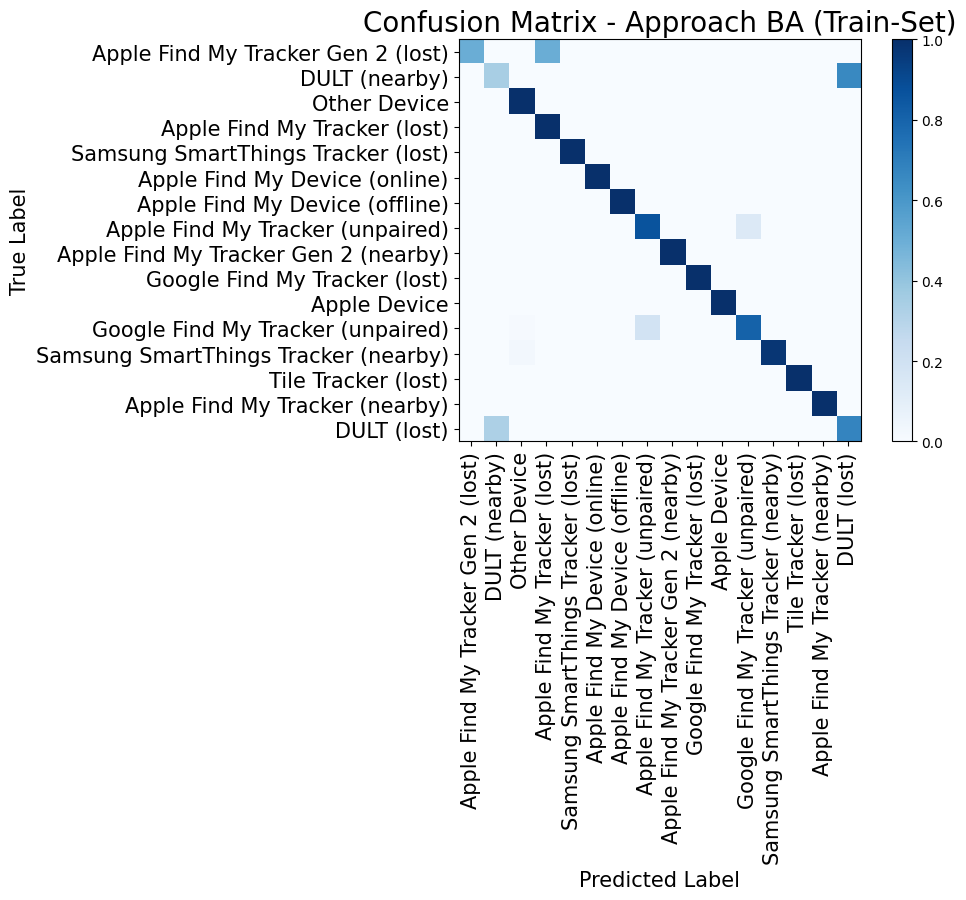

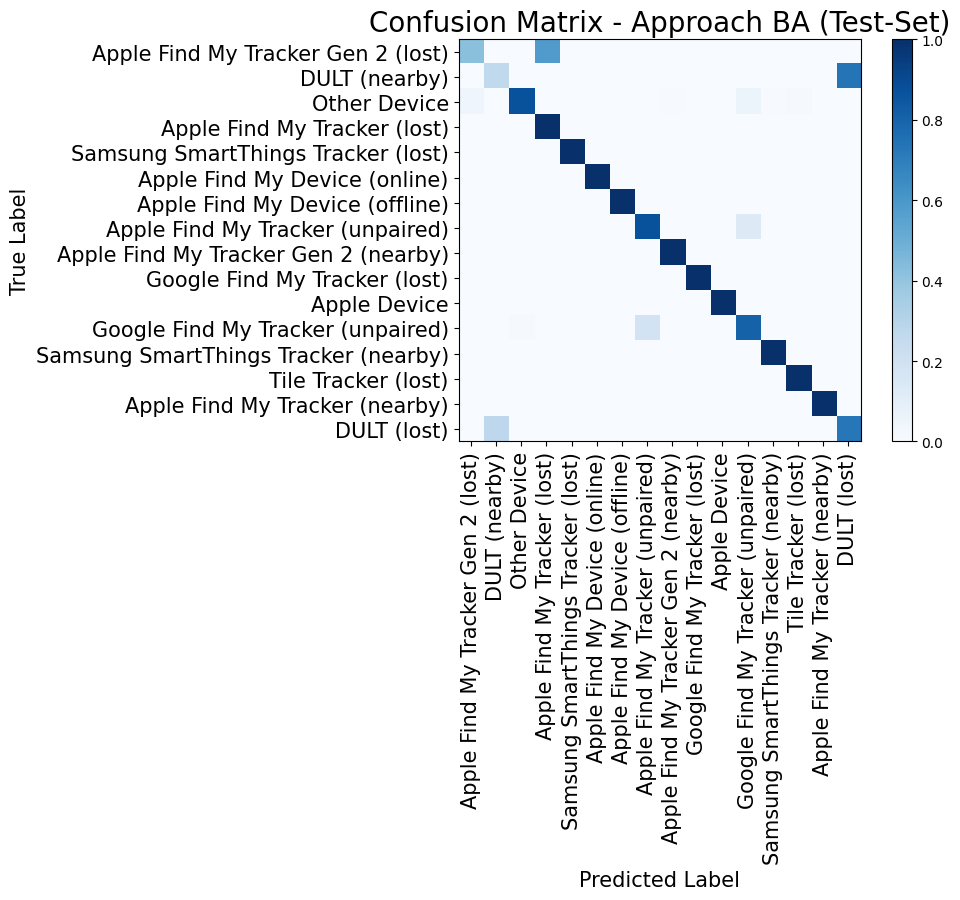


                                      precision    recall  f1-score   support

  Apple Find My Tracker Gen 2 (lost)     0.3750    0.4200    0.3962       200
                       DULT (nearby)     0.4818    0.2650    0.3419       200
                        Other Device     0.9992    0.8690    0.9296      3000
        Apple Find My Tracker (lost)     0.6329    1.0000    0.7752       200
  Samsung SmartThings Tracker (lost)     0.9852    1.0000    0.9926       200
       Apple Find My Device (online)     0.9852    1.0000    0.9926       200
      Apple Find My Device (offline)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     0.8018    0.8700    0.8345       200
Apple Find My Tracker Gen 2 (nearby)     0.9217    1.0000    0.9592       200
       Google Find My Tracker (lost)     0.9615    1.0000    0.9804       200
                        Apple Device     0.9569    1.0000    0.9780       200
   Google Find My Tracker (unpaired)     0.4667    0.8050    0

In [13]:
from plotting import plotMatrix, plotReport

preds = model.predict(x_train)
plotMatrix(y_train, preds, labels=list(set(labels_test)), savePath=PlotPath, name = "Approach BA (Train-Set)")

preds = model.predict(x_test)
plotMatrix(y_test, preds, labels=list(set(labels_test)), savePath=PlotPath, name = "Approach BA (Test-Set)")
plotReport(y_test, preds, labels=list(set(labels_test)))

In [14]:
count = 0
correct= 0
for pred, y in zip(y_test, preds):
    count += 1
    if pred == y:
        correct += 1

print("Accuracy (micro): ", float(correct/count)*100, "%")

Accuracy (micro):  87.06666666666666 %
